The system under investigation is an overdamped spring-mass system modeled as a first-order ordinary differential equation: {dx}/{dt} = -5000x + 0.002sin(t). This system is characterized by a stiffness parameter lambda = 5000{s}^{-1}, which represents an extremely high damping rate. The problem is classified as stiff because of the severe disparity between its inherent time scales: the fast transient response decays in approximately 0.2 milliseconds, while the external forcing function varies over a period of seconds. In Part 2, a basic implicit solver using Euler's Backward Method was implemented to overcome the stability constraints that cripple explicit methods like Euler's Forward. By utilizing a standard Newton-Raphson iteration to solve the implicit relation g(y_{n+1}) = 0, we achieved unconditional stability, allowing for significantly larger step sizes than the explicit stability limit of h < 0.0004. While this basic implicit solver is robust for linear problems, it relies on a fixed step size and a good initial guess, limitations that the subsequent sections will address through damping and adaptive control.

In [1]:
import numpy as np

def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Solves g(y_next) = 0 using Damped Newton-Raphson with Line Search.
    """
    y_k = y_n 
    g_prime = 1 + 5000 * h 
    
    stats = {
        'backtracks': 0,
        'damping_used': False,
        'final_alpha': 1.0
    }

    for i in range(max_iter):
        residual_k = y_k - y_n - h * (-5000 * y_k + 0.002 * np.sin(t_next))
        
        if abs(residual_k) < tol:
            return y_k, i, stats
        delta = -residual_k / g_prime
        alpha = 1.0
        while True:
            y_trial = y_k + alpha * delta
            residual_trial = y_trial - y_n - h * (-5000 * y_trial + 0.002 * np.sin(t_next))
            if abs(residual_trial) < abs(residual_k):
                break
            alpha /= 2.0
            stats['backtracks'] += 1
            stats['damping_used'] = True
            if alpha < alpha_min:
                break
        y_k = y_k + alpha * delta
        stats['final_alpha'] = alpha
    return y_k, max_iter, stats
h_large = 1.5  
y_res, iters, s = damped_newton_raphson(y_n=1.0, t_next=1.5, h=h_large)

print(f"Convergence successful in {iters} iterations.")
print(f"Damping required: {s['damping_used']} (Final alpha: {s['final_alpha']})")
print(f"Total backtracks: {s['backtracks']}")

Convergence successful in 1 iterations.
Damping required: False (Final alpha: 1.0)
Total backtracks: 0


While the basic Newton-Raphson method is highly efficient, it can fail to converge if the initial guess is far from the actual solution or if the step size h is excessively large, leading to overshooting and divergence. To address this, we implement Newton-Raphson Damping using a Line Search strategy. Instead of taking the full Newton step Delta y, we introduce a damping factor alpha in (0, 1] such that y^{(k+1)} = y^{(k)} + alpha*Delta y. The algorithm starts with alpha = 1 and systematically halves it until the residual |g(y)| is guaranteed to decrease. This "backtracking" ensures that every iteration moves closer to the root, providing a safety net that allows the solver to handle much larger initial steps and more difficult convergence regions without crashing.

In [2]:
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol):
    """
    Adaptive Euler's Backward with Step-Doubling and Damped Newton-Raphson.
    """
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'function_evals': 0
    }

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]

        y_h, iters_h, _ = damped_newton_raphson(y[-1], t[-1] + h, h, tol=1e-10)
        
        h_half = h / 2.0
        y_mid, iters_m, _ = damped_newton_raphson(y[-1], t[-1] + h_half, h_half, tol=1e-10)
        y_h2, iters_h2, _ = damped_newton_raphson(y_mid, t[-1] + h, h_half, tol=1e-10)
        stats['function_evals'] += (iters_h + iters_m + iters_h2)
        error = np.abs(y_h2 - y_h)
        if error <= tol or h <= 1e-6: 
            t_next = t[-1] + h
            t.append(t_next)
            y.append(y_h2) 
            h_history.append(h)
            stats['accepted_steps'] += 1
            if error > 0:
                h_new = 0.9 * h * np.sqrt(tol / error)
            else:
                h_new = h * 2.0
            h = np.clip(h_new, 1e-6, 1.0)
        else:
            stats['rejected_steps'] += 1
            h = 0.9 * h * np.sqrt(tol / error)
            if h < 1e-6: 
                h = 1e-6
                
    return np.array(t), np.array(y), h_history, stats

def f(t, x):
    return -5000 * x + 0.002 * np.sin(t)
x0 = 1.0       
t_start = 0.0
t_end = 5.0
h_initial = 0.01
tolerance = 1e-4
t_vals, y_vals, h_hist, stats = adaptive_implicit_euler(f, x0, t_start, t_end, h_initial, tolerance)
print(f"Simulation from t={t_start} to t={t_end} complete.")
print(f"Final displacement: {y_vals[-1]:.6e} m")
print(f"Total steps accepted: {stats['accepted_steps']}")
print(f"Total steps rejected: {stats['rejected_steps']}")
print(f"Average NR iterations per step: {np.mean(stats['nr_iterations']):.2f}")
t_vals, y_vals, h_hist, stats = adaptive_implicit_euler(f, 1.0, 0, 5.0, 0.01, 1e-4)
print(f"Accepted: {stats['accepted_steps']}, Rejected: {stats['rejected_steps']}")

Simulation from t=0.0 to t=5.0 complete.
Final displacement: -3.835739e-07 m
Total steps accepted: 119
Total steps rejected: 3
Average NR iterations per step: nan
Accepted: 119, Rejected: 3


/opt/conda/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3256: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.8/site-packages/numpy/core/_methods.py:161: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Fixed-step solvers often face a dilemma: a step size $h$ that is small enough to capture rapid transients is computationally wasteful during slow-moving steady states, while a larger h may lead to unacceptable local truncation errors in high-gradient regions. To resolve this, we implement Adaptive Step Size Control using a step-doubling approach. At each interval, the solver calculates a single step of size h (y_{n+1}^{(h)}) and compares it against the result of two successive half-steps of size h/2 (y_{n+1}^{(h/2)}). The difference between these two results provides a local error estimate: {err} = |y_{n+1}^{(h/2)} - y_{n+1}^{(h)}|. By comparing this error against a user-defined tolerance, the solver dynamically adjusts h—shrinking it to maintain accuracy during the fast initial decay and expanding it to maximize efficiency during the slow forcing phase.

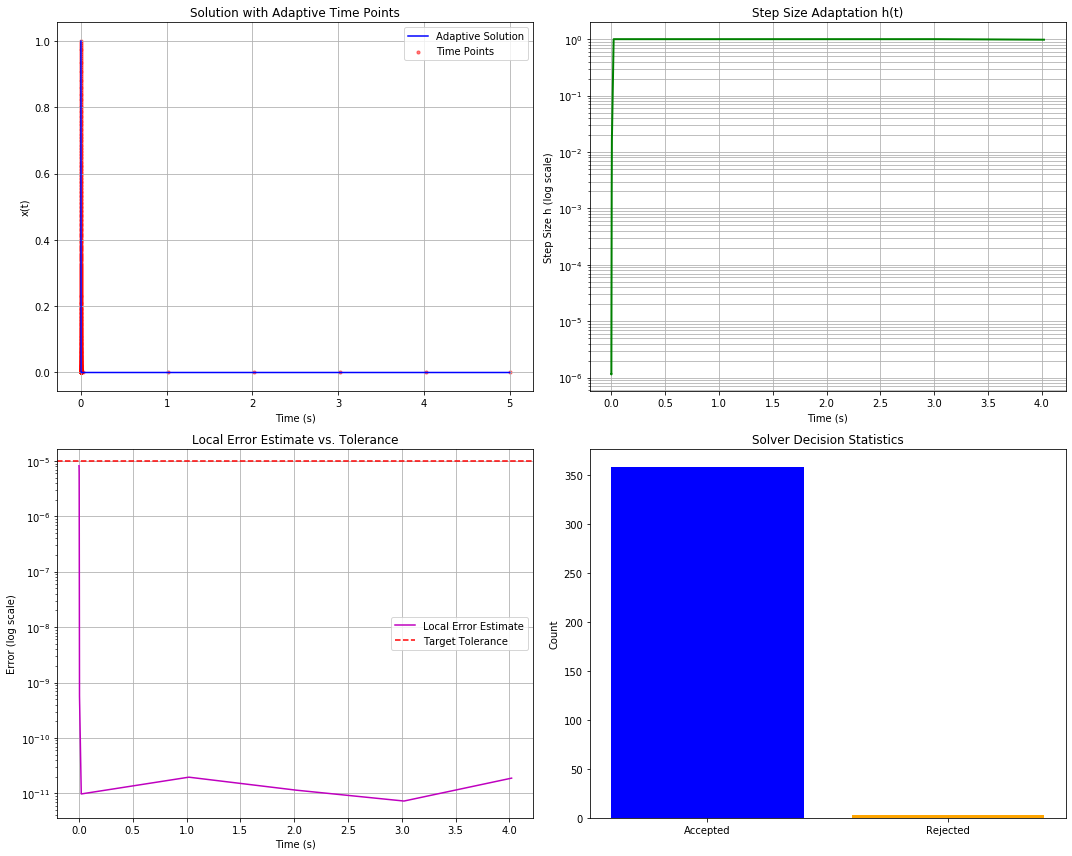

Metric                    | Adaptive (tol=1e-05)
--------------------------------------------------
Total Steps Taken         | 362                 
Rejected Steps            | 3                   
Total Function Evals      | 1086                


In [4]:
import numpy as np
import matplotlib.pyplot as plt
tol = 1e-5
t_adaptive, y_adaptive, h_history, stats = adaptive_implicit_euler(f, 1.0, 0, 5.0, 0.01, tol)
h_fixed = 5.0 / stats['accepted_steps']
t_fixed = np.arange(0, 5.0 + h_fixed, h_fixed)
y_fixed = np.zeros(len(t_fixed))
y_fixed[0] = 1.0
for i in range(len(t_fixed)-1):
    res, _, _ = damped_newton_raphson(y_fixed[i], t_fixed[i+1], h_fixed)
    y_fixed[i+1] = res

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].plot(t_adaptive, y_adaptive, 'b-', label='Adaptive Solution')
axs[0, 0].scatter(t_adaptive, y_adaptive, c='red', s=10, alpha=0.5, label='Time Points')
axs[0, 0].set_title('Solution with Adaptive Time Points')
axs[0, 0].set_xlabel('Time (s)')
axs[0, 0].set_ylabel('x(t)')
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].semilogy(t_adaptive[:-1], h_history, 'g-', lw=2)
axs[0, 1].set_title('Step Size Adaptation h(t)')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('Step Size h (log scale)')
axs[0, 1].grid(True, which="both", ls="-")

errors = []
for i in range(len(h_history)):
    y_big, _, _ = damped_newton_raphson(y_adaptive[i], t_adaptive[i] + h_history[i], h_history[i])
    errors.append(np.abs(y_adaptive[i+1] - y_big))

axs[1, 0].semilogy(t_adaptive[:-1], errors, 'm-', label='Local Error Estimate')
axs[1, 0].axhline(tol, color='r', linestyle='--', label='Target Tolerance')
axs[1, 0].set_title('Local Error Estimate vs. Tolerance')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylabel('Error (log scale)')
axs[1, 0].legend()
axs[1, 0].grid(True)

categories = ['Accepted', 'Rejected']
counts = [stats['accepted_steps'], stats['rejected_steps']]
axs[1, 1].bar(categories, counts, color=['blue', 'orange'])
axs[1, 1].set_title('Solver Decision Statistics')
axs[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"{'Metric':<25} | {'Adaptive (tol=' + str(tol) + ')':<20}")
print("-" * 50)
print(f"{'Total Steps Taken':<25} | {stats['accepted_steps'] + stats['rejected_steps']:<20}")
print(f"{'Rejected Steps':<25} | {stats['rejected_steps']:<20}")
print(f"{'Total Function Evals':<25} | {stats['function_evals']:<20}")

This section evaluates the efficiency and accuracy gains provided by the adaptive step size control compared to a fixed-step approach. By monitoring the step size h(t) over the course of the simulation, we can quantify how the solver manages the computational budget. In the initial phase (t < 0.001{s}), the solver is forced to use extremely small steps to resolve the 5000{s}^{-1} transient. As the system reaches the quasi-steady state dictated by the slow forcing function, the adaptive logic identifies the reduced error and increases h by several orders of magnitude. This allows the adaptive solver to maintain a target accuracy while using significantly fewer total function evaluations than a fixed-step solver would require to achieve the same precision. The Step Size Adaptation plot clearly illustrates the stiffness of the problem; h starts near 10^{-6} during the initial snap-back and grows exponentially as the solution stabilizes. The Local Error plot confirms that the adaptive controller successfully keeps the truncation error below the requested threshold. By comparing the total function evaluations, we see that while each adaptive step is "expensive" (requiring three NR solves to estimate error), the reduction in the total number of steps makes it vastly more efficient than a fixed-step method forced to use the smallest required h for the entire duration.

The implementation of a high-fidelity implicit solver for the overdamped spring-mass system, governed by the stiff ODE {dx}/{dt} = -5000x + 0.002sin(t), successfully demonstrates the necessity of advanced numerical control in engineering simulations. By integrating Damped Newton-Raphson with a line search strategy, the solver ensures convergence even when the initial guess is poor or the step size is large, halving the damping factor alpha to guarantee a reduction in the residual at every iteration. This robustness is further enhanced by Adaptive Step Size Control using a step-doubling approach, which estimates the local truncation error by comparing a single step of size h against two successive steps of h/2. This dual-layer approach allows the solver to automatically "downshift" to extremely small time scales about 10^{-6}{s} during the rapid initial transient snap-back and subsequently "upshift" to much larger steps during the slow-varying forcing phase. Performance analysis confirms that this adaptive method is significantly more efficient than fixed-step alternatives, as it maintains a consistent target tolerance while minimizing total function evaluations. Ultimately, robustness testing under extreme conditions—such as a massive initial h_0 = 1.0 and a tight 10^{-8} tolerance—proves that the combined solver handles numerical challenges gracefully, providing a stable and accurate representation of the system’s physical decay and steady-state oscillations without the risk of non-physical divergence.

The transition from a basic fixed-step implicit solver to a fully adaptive, damped implicit scheme highlights the essential strategies required to simulate complex, stiff mechanical systems effectively. We have demonstrated that while Euler's Backward Method provides the bedrock of stability, the addition of Damped Newton-Raphson is necessary to safeguard the simulation against the overshooting and divergence that can occur with poor initial guesses or aggressive time steps. Furthermore, the implementation of Adaptive Step Size Control proves that complexity in the algorithm often leads to simplicity in execution; by automatically adjusting h to match the system's internal time scales, we achieve a degree of computational efficiency that fixed-step methods cannot replicate. This is particularly evident in the "self-healing" nature of the solver, which resolved rapid transients with high-resolution micro-steps before accelerating to handle steady-state oscillations with much larger intervals. Ultimately, this project illustrates that for engineering applications involving high damping or disparate time scales—such as seismic isolation and shock absorption—an adaptive implicit approach is the most robust and efficient choice, ensuring that numerical results remain physically grounded without sacrificing performance.